# Imports

In [331]:
from ModifiedNEAT.nn.base import NeatModule
from load_data import MnistDataloader
from ModifiedNEAT.util.storage import STORAGE_DIR
from ModifiedNEAT.util.qol import manage_params
from ModifiedNEAT.util.datetime import clock, eta
from ModifiedNEAT.util.storage import save, load
from ModifiedNEAT.util.fancy_text import CM, Fore

import ModifiedNEAT as meat
import ModifiedNEAT.nn as mnn
import ModifiedNEAT.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import warnings

from torch import Tensor
from torch.optim import Optimizer
from torch.nn.utils import clip_grad_norm_
from torchvision import transforms
from numpy import ndarray as CPUArray
from typing import Union
from copy import deepcopy
from matplotlib.pyplot import Axes
from numba.core.errors import NumbaPerformanceWarning

In [332]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
GENOMES = 10
meat.set_device(DEVICE)
meat.util.storage.set_storage_location("../../storage/")
meat.device()

'cpu'

In [333]:
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

# Load Data

In [334]:
ABS_PATH = './mnist_data/'
loader = MnistDataloader(
    f"{ABS_PATH}train-images.idx3-ubyte",
    f"{ABS_PATH}train-labels.idx1-ubyte",
    f"{ABS_PATH}t10k-images.idx3-ubyte",
    f"{ABS_PATH}t10k-labels.idx1-ubyte",
)
RESIZE = (10, 10)
(train_inp, train_out), (eval_inp, eval_out) = loader.load_data(
    GENOMES, 200, 1000, resize=RESIZE, rand_rot=False, rand_flip=False, batch_size=128,
    normalize=True,
    device='cpu', dtype=DTYPE
)
train_inp.shape, train_out.shape, eval_inp.shape, eval_out.shape

Loaded 200 records.
Loaded 1000 records.


(torch.Size([10, 200, 1, 10, 10]),
 torch.Size([10, 200]),
 torch.Size([10, 1000, 1, 10, 10]),
 torch.Size([10, 1000]))

In [335]:
def tensor_memory(tensor: Tensor):
    """

    :param tensor: PyTorch tensor
    :return: Memory in Megabytes
    """
    return tensor.numel() * tensor.element_size() / (1024 ** 2)

In [336]:
tensor_memory(eval_inp)

3.814697265625

In [337]:
[(torch.max(t).cpu(), torch.min(t).cpu()) for t in [train_inp, eval_inp]]

[(tensor(0.9874), tensor(0.)), (tensor(0.9961), tensor(0.))]

In [338]:
train_inp.device, train_inp.dtype, train_inp.device, train_out.dtype

(device(type='cpu'), torch.float32, device(type='cpu'), torch.int64)

In [339]:
torch.max(train_inp)

tensor(0.9874)

In [340]:
IMG_SHAPE = train_inp.shape[3:]
IMG_SHAPE

torch.Size([10, 10])

# View data

In [341]:
def show_image(image: Tensor, title: str = None, size: tuple[int, int] = None, cmap='binary', axis: Axes = None):
    if size is None:
        size = (360, 360)
    if image.ndim == 3:
        image = image.permute(1, 2, 0)
    elif image == 2:
        pass
    else:
        raise ValueError(f"Unsupported ndim")
    image = image.cpu().float()
    if axis is None:
        _, axis = plt.subplots(1, 1, figsize=(size[0] * 0.01, size[1] * 0.01))
    axis.imshow(image, cmap=cmap)
    if title is not None:
        axis.set_title(title)
    axis.set_axis_off()
    if axis is None:
        plt.show()

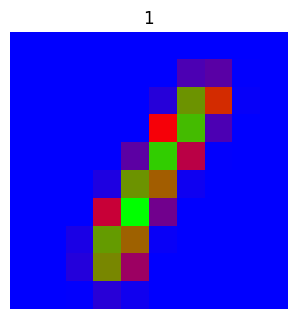

In [342]:
rand_train_idx = np.random.randint(0, len(train_inp))
show_image(train_inp[0, rand_train_idx], train_out[0, rand_train_idx].item(), cmap='brg')

In [343]:
def show_batch(images: Tensor, predictions: Tensor = None, labels: Tensor = None, columns=8,
               size: tuple[int, int] = None, cmap='binary', no_axes=True):
    if size is None:
        size = (720, 1080)
    if images.ndim == 4:
        images = images.permute(0, 2, 3, 1)
    elif images == 3:
        pass
    else:
        raise ValueError(f"Unsupported ndim")

    images = images.cpu().float()
    rows = math.ceil(len(images) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(size[1] * 0.01, size[0] * 0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for index, (axis, image) in enumerate(zip(axes, images)):
        axis.imshow(image, cmap=cmap)
        title = ''
        if predictions is not None:
            title += f"P={predictions[index].cpu().item()}"
        if labels is not None:
            title += f"L={labels[index].cpu().item()}"
        if len(title) > 0:
            axis.set_title(title)
        if no_axes:
            axis.set_axis_off()
    plt.show()

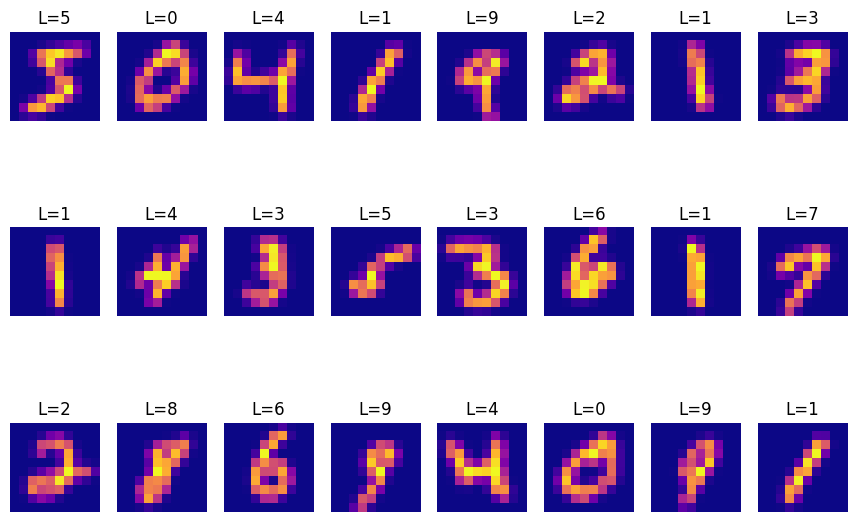

In [344]:
show_batch(train_inp[0, :24], labels=train_out[0, :24], cmap='plasma')

# Model Architecture

In [345]:
from typing import Iterable

class Average(nn.Module):
    def __init__(self, dims=None, keepdims=False):
        super(Average, self).__init__()
        self.dims = dims
        self.keepdims = keepdims

    def forward(self, input: Tensor) -> Tensor:
        return torch.mean(input, dim=self.dims, keepdim=self.keepdims)

class Permute(nn.Module):
    def __init__(self, dims: int | Iterable[int]):
        super(Permute, self).__init__()
        if not isinstance(dims, Iterable):
            dims = [dims]
        self.dims = tuple(dims)

    def forward(self, input: Tensor) -> Tensor:
        extra = tuple(range(max(0, input.ndim-len(self.dims))))
        return input.permute(extra+self.dims)

    def extra_repr(self):
        return f"dims={self.dims}"

class SimpleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, dim_size: int, layers: int, kernel_size: int, img_size: tuple[int, int],
                 fc_size: int, div=1, actv=nn.SiLU(), bias=False, device='cpu', dtype=torch.float32):
        super().__init__()
        sequence = nn.ModuleList()
        padding = 0
        for layer_idx in range(layers+1):
            # size_ = tuple([dim - (kernel_size-1) * layer_idx for dim in img_size])
            if layer_idx < layers:
                # if layer_idx == 0:
                sequence.append(mnn.Conv2d(
                    inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                    outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                    kernel_size=kernel_size, bias=bias if layer_idx > 0 else True, 
                    device=device, dtype=dtype,
                    padding=padding, padding_mode='zeros'
                ))
                # else: # NOTE: Too computationally expensive
                #    sequence.append(mnn.ResidualBlock(
                #         inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                #         outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                #         kernel_size=kernel_size, bias=bias, device=device, dtype=dtype,
                #         padding=padding, padding_mode='zeros', image_ndim=2, norm_groups=1,
                #    ))
                # if layer_idx == layers-1:
                sequence.append(
                    mnn.GroupNorm(1, dim_size+(dim_size//div*layer_idx) if layer_idx != layers else outputs,
                                    bias=bias, device=device, dtype=dtype)
                )
                sequence.append(actv)
            else:
                # fc_inputs = (dim_size+(dim_size//div*(layers-1))) * math.prod(img_size)
                ndim = len(img_size) + 1 # Convolution dimensions + Feature dimension
                permutation = list(range(-ndim+1, 0)) + [-ndim]
                sequence.extend([
                    Permute(permutation),
                    nn.Flatten(-(len(img_size)+1), -1),
                    nn.AdaptiveAvgPool1d(fc_size),
                    mnn.Linear(fc_size, outputs * 2, bias=True, device=device, dtype=dtype)
                ])
        self.sequence = mnn.Sequential(*sequence)
        # self.mean_std = mnn.Linear(fc_size, outputs * 2, bias=bias, device=device, dtype=dtype)
        # self.mean = mnn.Linear(fc_size, outputs, bias=bias, device=device, dtype=dtype)

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.dim_size   = dim_size
        self.kernel_size = kernel_size
        self.layers     = layers
        self.div        = div
        self.bias       = bias
        self.fc_size    = fc_size

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        tensor = (tensor - 0.5) * 2.0
        tensor = self.sequence(tensor, keys=keys)
        # mean, log_std = torch.chunk(self.mean_std(tensor, keys=keys), 2, -1)
        mean, log_std = torch.chunk(tensor, 2, -1)
        std = torch.exp(log_std)
        # std_min, std_max = -2, 0.3
        # std_range = std_max - std_min
        # mean, std = torch.tanh(mean) * 2, torch.pow(10, std_min + torch.sigmoid(log_std) * std_range)
        # dist = torch.distributions.Normal(mean, std)
        # tensor = dist.sample()
        # tensor = torch.sigmoid(tensor * torch.pi)
        # # tensor = self.mean(tensor, keys=keys)
        # # tensor = F.log_softmax(tensor, dim=-1)
        tensor = mean + (std * torch.randn_like(std))
        return tensor

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None):
        return torch.argmax(self.forward(tensor, keys), dim=-1)

DyParam = Union[int, list[int]]

class EnsembleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, kernel_sizes: DyParam, dim_sizes: DyParam, layers: DyParam,
                 img_size: tuple[int, int], fc_size: int, divs: DyParam, actv=nn.SiLU(),
                 bias=False, device='cpu', dtype=torch.float32):
        super(EnsembleCNN, self).__init__()
        if isinstance(kernel_sizes, (int, float)):
            kernel_sizes = [kernel_sizes]

        self.networks: list[SimpleCNN] = nn.ModuleList()
        for k_idx, kernel_size in enumerate(kernel_sizes):
            dim_size    = dim_sizes if isinstance(dim_sizes, (int, float)) else dim_sizes[min(k_idx, len(dim_sizes)-1)]
            layer_num   = layers if isinstance(layers, (int, float)) else layers[min(k_idx, len(layers)-1)]
            div         = divs if isinstance(divs, (int, float)) else divs[min(k_idx, len(divs)-1)]
            self.networks.append(SimpleCNN(
                inputs, outputs, dim_size, layer_num, kernel_size, img_size, fc_size, div, actv, bias, device, dtype
            ))

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.img_size   = img_size
        self.bias       = bias

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        summation = []
        for module in self.networks:
            summation.append(module(tensor, keys=keys))
        return torch.sum(torch.stack(summation), dim=0)

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        return torch.argmax(self.forward(tensor, keys=keys, verbose=verbose), dim=-1)

    def guess(self, tensor, keys: Union[int, list[int]] = None):
        logits = self.forward(tensor, keys=keys)
        dist = torch.distributions.Categorical(F.softmax(logits, -1).float())
        return dist.sample()

    def save(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = network.state_dict()
            save(params, name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)

    def load(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = load(name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)
            if params is not None:
                network.load_state_dict(params)

In [346]:
test_inputs = torch.randn(1, 3, 1, *IMG_SHAPE, dtype=DTYPE)
# CHANNELS = (
#     [32 + 16 * max(0, 4*n-1) for n in range(3)],
# )
_KERNELS = (3, 5, 7)
_DIMENSIONS = (32, 48, 64)
CHANNELS_LAYERS = (3, 2, 1)
test_model = EnsembleCNN(
    inputs=1, outputs=10, kernel_sizes=_KERNELS, dim_sizes=_DIMENSIONS,
    layers=CHANNELS_LAYERS, fc_size=256,
    img_size=IMG_SHAPE, divs=2, actv=nn.SiLU(),
    bias=False, device='cpu', dtype=DTYPE
)
print(test_model)
with torch.no_grad():
    test_outputs = test_model.evaluate(test_inputs, verbose=2)
    # test_model.save()
    # test_model.load()
test_outputs, test_outputs.shape

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=32, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=zeros)
        (1): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-09, affine=True, bias=False)
        (2): SiLU()
        (3): Conv2d[NeatModule](channels_in=32, channels_out=48, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
        (4): GroupNorm[NeatModule](groups=1, channels=48, eps=1e-09, affine=True, bias=False)
        (5): SiLU()
        (6): Conv2d[NeatModule](channels_in=48, channels_out=64, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
        (7): GroupNorm[NeatModule](groups=1, channels=64, eps=1e-09, affine=True, bias=False)
        (8): SiLU()
        (9): Permute(dims=(-2, -1, -3))
        (10): Flatten(st

(tensor([[4, 8, 0]]), torch.Size([1, 3]))

# Create Model

In [347]:
def model_size(model: meat.NeatModule):
    return np.sum([param.numel() * param.element_size() for param in model.parameters()]) / (1024 ** 2)

In [348]:
def model_params(model: meat.NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [349]:
INPUT_DIMS = 1
OUTPUT_DIMS = 10
DIM_SIZE = 16
# DEPTH = 3
LAYERS = 2
BIAS = False

In [350]:
MODEL = EnsembleCNN(
    inputs=INPUT_DIMS, outputs=OUTPUT_DIMS, kernel_sizes=(3,),
    dim_sizes=(DIM_SIZE,), layers=(LAYERS,), img_size=IMG_SHAPE, fc_size=128, divs=2,
    bias=BIAS, device=DEVICE, dtype=DTYPE, actv=nn.SiLU()
)
MODEL

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=16, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=zeros)
        (1): GroupNorm[NeatModule](groups=1, channels=16, eps=1e-09, affine=True, bias=False)
        (2): SiLU()
        (3): Conv2d[NeatModule](channels_in=16, channels_out=24, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
        (4): GroupNorm[NeatModule](groups=1, channels=24, eps=1e-09, affine=True, bias=False)
        (5): SiLU()
        (6): Permute(dims=(-2, -1, -3))
        (7): Flatten(start_dim=-3, end_dim=-1)
        (8): AdaptiveAvgPool1d(output_size=128)
        (9): Linear[NeatModule](inputs=128, outputs=20, bias=True)
      )
    )
  )
)

# Create Population

In [351]:
CONFIG = meat.Config('mnist', './')

In [352]:
MULTIPLIER = 0.1
CONFIG.genome.init_type             = 'normal'
CONFIG.genome.weight_init_mean      = 0.0
CONFIG.genome.weight_init_std       = 0.3142
CONFIG.genome.weight_min_value      = -np.inf
CONFIG.genome.weight_max_value      = +np.inf
CONFIG.genome.weight_mutate_power   = 1e-1
CONFIG.genome.weight_mutate_rate    = 0.60
CONFIG.genome.weight_replace_rate   = 0.00
CONFIG.genome.weight_add_prob       = 1.00
CONFIG.genome.weight_del_prob       = 1e-9
CONFIG.genome.param_epsilon         = 0e-12
CONFIG.genome.single_structural_mutation = False
CONFIG.reproduction.min_species_size = GENOMES
CONFIG.reproduction.purge           = 1
CONFIG.reproduction.survival_threshold = 0.50
CONFIG.reproduction.darwin_multiplier = 0.33
CONFIG.reproduction.elitism         = 0.50
CONFIG.species.compatibility_threshold = np.inf
CONFIG.stagnation.max_stagnation    = 1
CONFIG.stagnation.species_elitism   = 1
CONFIG.save()
CONFIG.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration mnist.mnc.json
Created configuration 'GENOME CONFIG' in NEAT Configuration mnist.mnc.json
Created configuration 'SPECIES CONFIG' in NEAT Configuration mnist.mnc.json
Created configuration 'STAGNATION CONFIG' in NEAT Configuration mnist.mnc.json
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration mnist.mnc.json
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 164578
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration mnist.mnc.json
weight_init_mean          = 0.0
weight_init_std           = 0.3142
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.1
weight_mutate_rate        = 0.6
weight_replace_rate       = 0.0
weight_add_prob           = 1.0
weight_del_prob           = 1e-09
param_epsilon             = 0.0
compatibility_disjoint_coefficient = 1.0
compati

In [353]:
POPULATION = meat.Population(GENOMES, MODEL, CONFIG, init_reporter=True)

Initialized genomes in  in 0.54s
Ran distance kernel in 0.0 s
Created distances cache in 0.49 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.49 s
Mean genetic distance 0.221, standard deviation 0.075, with 1 species


In [354]:
# POPULATION.load_dict(name="mnist", file_no=None, verbose=True)

In [355]:
def faulty_genome(key: int):
        return any(torch.any(p.data[p.mapping[key]] == 0) for p in MODEL.neat_parameters())
[k for k in POPULATION.genomes.keys() if faulty_genome(k)]

[]

In [356]:
test_key = POPULATION.best_genome.key if POPULATION.best_genome is not None else list(POPULATION.genomes.keys())[0]
test_index = MODEL.mapping[test_key]
# for param in MODEL.parameters():
#     full_zero_param = torch.all(param[test_index] == 0).cpu().item()
#     if full_zero_param:
#         print(f"Found zero parameter: {param.shape}")
# for module in MODEL.modules():
#     if not isinstance(module, NeatModule):
#         print(f"Found non-NEAT parameter: {module.__class__.__name__}")
test_key, test_index, MODEL

(760,
 0,
 EnsembleCNN(
   (networks): ModuleList(
     (0): SimpleCNN(
       (sequence): Sequential[NeatModule](
         (0): Conv2d[NeatModule](channels_in=1, channels_out=16, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=zeros)
         (1): GroupNorm[NeatModule](groups=1, channels=16, eps=1e-09, affine=True, bias=False)
         (2): SiLU()
         (3): Conv2d[NeatModule](channels_in=16, channels_out=24, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
         (4): GroupNorm[NeatModule](groups=1, channels=24, eps=1e-09, affine=True, bias=False)
         (5): SiLU()
         (6): Permute(dims=(-2, -1, -3))
         (7): Flatten(start_dim=-3, end_dim=-1)
         (8): AdaptiveAvgPool1d(output_size=128)
         (9): Linear[NeatModule](inputs=128, outputs=20, bias=True)
       )
     )
   )
 ))

In [357]:
f"{model_size(MODEL):.3f}", f"{model_params(MODEL):.2e}"

('0.238', '6.24e+04')

In [358]:
SCHEDULERS = [
    # optim.scheduler.CosineAnnealing(CONFIG, 50, 1e-2, 'weight_mutate_power', True, True),
    # optim.scheduler.RandomAnnealing(CONFIG, 1e-3, 1e-1, 'weight_mutate_power', True),
    optim.scheduler.CosineAnnealing(CONFIG, 20, 0.05, 'weight_mutate_rate', True, True),
    # optim.scheduler.RandomAnnealing(CONFIG, 0.00, 0.70, 'weight_mutate_rate', False),
    # optim.scheduler.CosineAnnealing(CONFIG, 100, 0.01, 'weight_replace_rate', True, True),
]

In [359]:
SCHEDULERS[0].step()
f"{CONFIG.genome.weight_mutate_power:.4e}"

'1.0000e-01'

In [360]:
# POPULATION.load_dict(name="mnist", file_no=None, verbose=True)

# Train

In [361]:
def cross_entropy_loss(logits: Tensor, targets: Tensor):
    """
    Gets the cross entropy loss for genomes, given logits and targets.
    :param logits: Assumes last dimension is for logit probabilities.
    :param targets: Assumes last dimension is for target values.
    :return:
    """
    assert logits.ndim >= 2
    assert logits.ndim -1 == targets.ndim
    genome_num, classes_num = logits.shape[0], logits.shape[-1]
    return F.cross_entropy(
        logits.view(genome_num, -1, classes_num).mT,
        targets.view(genome_num, -1),
        reduction="none"
    ).mean(dim=-1)

In [362]:
test_classes    = 10
test_genomes    = 3
test_batches    = 32
test_seq_len    = 4
test_device     = 'cpu' if torch.cuda.is_available() else 'cpu'
test_tensor_logt = torch.normal(0, 3.14e-1, (test_genomes, test_batches, test_seq_len, test_classes)).to(test_device)
test_tensor_targ = torch.randint(0, test_classes, (test_genomes, test_batches, test_seq_len)).to(test_device)
test_losses = cross_entropy_loss(test_tensor_logt, test_tensor_targ)
test_losses_normal = F.cross_entropy(test_tensor_logt.permute(0, -1, 1, 2), test_tensor_targ, reduction='none').mean(-1)
test_tensor_logt[:2, :2, :3,], test_losses_normal[:5].mean(-1), test_losses.shape, test_losses[:5]

(tensor([[[[-0.4127, -0.2982,  0.1101,  0.4839,  0.5837, -0.3114,  0.2445,
            -0.7116, -0.3386, -0.2401],
           [ 0.0807,  0.0069,  0.1084, -0.6038,  0.3312,  0.1129,  0.0636,
            -0.1671, -0.0685,  0.1460],
           [-0.5241, -0.0856, -0.1436, -0.2222,  0.7069,  0.4733,  0.4811,
            -0.0475,  0.0849, -0.2747]],
 
          [[-0.0295, -0.0926,  0.3598,  0.4368,  0.0546, -0.3983, -0.0927,
            -0.0380, -0.1899,  0.0490],
           [-0.8013,  0.3079,  0.0946, -0.2119,  0.2239,  0.1281, -0.1003,
             0.1291,  0.5020, -0.7108],
           [ 0.1224,  0.0484, -0.0776,  0.1639, -0.0440,  0.0391,  0.0503,
            -0.1462,  0.2721,  0.4589]]],
 
 
         [[[-0.2829,  0.1928,  0.0123,  0.0248, -0.5126, -0.0306,  0.0599,
            -0.1712, -0.2385,  0.2550],
           [-0.0686, -0.0239, -0.4328,  0.3273,  0.4438, -0.0770,  0.2257,
             0.0414,  0.2978,  0.0387],
           [ 0.0959, -0.0479, -0.3580,  0.5693,  0.3617,  0.0736,  0.39

In [363]:
%%timeit -n 10 -r 3
_test_val = torch.stack([
    F.cross_entropy(log.view(-1, test_classes), targ.view(-1).to(torch.long)) for log, targ in zip(test_tensor_logt, test_tensor_targ)
])[:5]

172 μs ± 30.8 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [364]:
%%timeit -n 10 -r 3
_test_val = cross_entropy_loss(test_tensor_logt, test_tensor_targ)

169 μs ± 29 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [365]:
MODEL(eval_inp[:len(POPULATION.genomes), :10].to(DEVICE, DTYPE), verbose=2).shape

torch.Size([10, 10, 10])

In [366]:
def get_batches(records: int, batch_size: int = None, shuffle=False):
    if batch_size is None:
        batch_size = records
    assert records > 0
    if batch_size is None:
        batch_size = records
    else:
        assert batch_size > 0
        batch_size = min(batch_size, records)

    indices: list[int] = list(range(records))
    if shuffle:
        random.shuffle(indices)
    batch_indices: list[list[int]] = list()
    batch: list[int] = list()
    for i, index in enumerate(indices):
        batch.append(index)
        batch_is_filled = len(batch) == batch_size
        no_more_records = i == len(indices) - 1 and not batch_is_filled
        if batch_is_filled or no_more_records:
            batch_indices.append(batch)
            batch = list()

    return batch_indices

In [367]:
BATCH_SIZE = 64

In [368]:
def get_accuracy(model: EnsembleCNN, inputs, outputs, batch_size: int, guess=False, verbose=False,
                 keys: Union[int, list[int]] = None, mean=False):
    if keys is not None and not isinstance(keys, (tuple, list)):
        keys = [keys]
    if keys is not None:
        mapping = POPULATION.get_mapping()
        key_indices = [mapping[key] for key in keys]
        inputs, outputs = inputs[key_indices], outputs[key_indices]

    torch.cuda.empty_cache()
    batch_indices = get_batches(inputs.shape[1], batch_size, True)
    summation = {index: 0 for index in range(len(outputs))}
    elements = {index: 0 for index in range(len(outputs))}
    # print(inputs.shape, outputs.shape, len(batch_indices), max([len(batch) for batch in batch_indices]))
    ts = clock.perf_counter()
    for step, batch in enumerate(batch_indices):
        with torch.no_grad():
            images = inputs[:, batch].to(model.device)
            target: Tensor = outputs[:, batch].to(model.device)
            if not guess:
                prediction: torch.Tensor = model.evaluate(images, keys=keys)
            else:
                prediction: torch.Tensor = model.guess(images, keys=keys)
            total = prediction == target
            for index, (sub_total, sub_target) in enumerate(zip(total, target)):
                summation[index] += sub_total.sum().item()
                elements[index] += sub_target.numel()
        if verbose:
            eta(ts, step+1, len(batch_indices), f"Getting accuracy")
    if verbose:
        print(f"\nCalculated accuracy in {clock.perf_counter()-ts:.2f}s")

    accuracy = {index: s / e for (index, s), e in zip(summation.items(), elements.values())}
    torch.cuda.empty_cache()
    if not mean:
        return np.max(list(accuracy.values())).item()
    else:
        return np.mean(list(accuracy.values())).item()
MODEL.eval();

In [369]:
get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, verbose=True, keys=list(POPULATION.genomes.keys()))

Getting accuracy: progress=100% eta=0sec
Calculated accuracy in 0.62s


0.11

In [370]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=list(POPULATION.genomes.keys())))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, keys=list(POPULATION.genomes.keys())))*100

(85.5, 88.9)

In [371]:
train_inp.shape

torch.Size([10, 200, 1, 10, 10])

In [372]:
test_predictions = MODEL(train_inp[:1, :6].to(MODEL.device), keys=test_key, verbose=3)
test_predictions.cpu().float().numpy()

array([[[ 1.644078  ,  0.27635613,  0.29105222,  0.48394135,
          0.32458454,  0.52334297,  0.55547756,  1.1998911 ,
         -0.93340665, -0.4010376 ],
        [ 1.3821003 ,  1.4375335 ,  1.0048134 ,  1.654356  ,
          0.15913312, -0.87405753, -1.9316835 ,  1.1713452 ,
          0.2701283 , -1.436283  ],
        [ 0.6518231 ,  0.8558975 ,  2.1606474 ,  1.2963374 ,
         -0.15034923,  0.00926089,  0.29231486,  0.11389358,
         -0.57328075,  0.9453628 ],
        [ 1.4309009 , -0.0882849 ,  0.5095124 , -1.8937848 ,
          0.4780239 ,  1.8815086 ,  0.6717546 ,  0.15208653,
         -0.36650404, -1.108269  ],
        [ 2.6402137 , -0.09453331,  1.4536207 , -0.6077    ,
          0.5250083 , -0.32634836,  0.11774543,  0.8533393 ,
         -0.2712564 ,  0.43926346],
        [-0.35344827, -0.19802228,  1.590909  , -2.3913686 ,
          0.9971763 , -0.43072698,  0.19542456,  0.410002  ,
         -0.8531971 , -0.800596  ]]], dtype=float32)

In [373]:
def eta(time_start, units_done, units_total, text=''):
    time_done = clock.perf_counter() - time_start
    progress = round(units_done / units_total * 100)
    rem = round(time_done / units_done * (units_total - units_done))
    print(f"\reta={rem}s", end='')

In [374]:
from ModifiedNEAT.rl.base import Algorithm, ReplayBuffer

class Trainer(Algorithm):
    def __init__(self, eval_func, model, population, schedulers=None, device='cpu', dtype=torch.float32, **options):
        for var in ['schedulers', 'device', 'dtype']:
            if var in options:
                del options[var]
        super().__init__(population, schedulers, device, dtype, **options)
        self.model = model
        self.evaluate = eval_func

        self.primary.add_buffers('score', 'ep_map')

        # ---------- Options ----------
        self.alpha = manage_params(options, 'alpha', 1.0)

        # ---------- Logging ----------
        pass

    def updates_scores(self, losses: Tensor):
        self.handle_episode_mapping(False, force_reset=True)
        scores = -losses
        # scores = (scores - scores.mean()) / (scores.std() + 1e-8)
        # minimum, maximum = torch.min(scores), torch.max(scores)
        norm_scores = scores # (scores - minimum) / (maximum - minimum + 1e-12)
        # norm_scores = (norm_scores - 0.5) * 2
        self.primary.update(
            score=norm_scores,
            ep_map=self.episode_mapping[0]
        )

        self.steps_done += 1
        self.episodes_done = max(self.episode_mapping.values()) + 1
        self.prev_steps_done = self.steps_done

    def get_returns(self):
        scores, episode_mapping = self.primary.rollout(['score', 'ep_map'], as_list=True, stack=True)
        self.sort_episodes(episode_mapping, scores)
        cum_scores = self.compute_returns(scores, 0, 0, self.alpha, True, episode_mapping)
        return cum_scores, episode_mapping

    def set_scores(self):
        scores, episode_mapping = self.primary.rollout(['score', 'ep_map'], as_list=True, stack=True)
        self.sort_episodes(episode_mapping, scores)
        cum_scores = self.compute_returns(scores, 0, 0, self.alpha, True, episode_mapping)
        for key, score in cum_scores.items():
            self.population.genomes[key].fitness = torch.mean(score).cpu().item()

    def run(self, epochs: int, display=True, checkpoint=1):
        torch.cuda.empty_cache()
        losses: list[float] = []
        accuracies: list[float] = []
        genomes: list[int] = []
        mean = []
        std = []

        ts = clock.perf_counter()
        for scheduler in self.schedulers:
            scheduler.reset()
        best_score = None if self.population.best_genome is None else self.population.best_genome.fitness
        save_state = self.population.save_dict()[0]
        try:
            for epoch in range(epochs):
                # gs = list(self.population.genomes.keys())
                # print(f"Genomes: {gs[:5]}... {gs[-5:]}")
                self.population.run(
                    self.evaluate, 1, trainer=self,
                    losses=losses, accuracies=accuracies, genomes=genomes, mean=mean, std=std,
                    epoch=epoch, verbose=False if epoch==0 else False
                )
                for scheduler in self.schedulers:
                    scheduler.step()
                if epoch % checkpoint == 0 and (best_score is None or self.population.best_genome.fitness >= best_score):
                    best_score = self.population.best_genome.fitness
                    save_state = self.population.save_dict()[0]

                eta(ts, epoch+1, epochs, f"NEAT training: loss={losses[-1]:.4f} ({min(losses):.4f})")
        except KeyboardInterrupt as e:
            print(CM(e, Fore.LIGHTRED_EX))
        except Exception as e:
            raise e
        # except (RuntimeError, StopIteration, ValueError) as e:
        #     raise e
        self.population.load_dict(save_state, verbose=False)
        print(f"\nFinished NEAT training in {clock.perf_counter() - ts:.1f}s. Best genome: {self.population.best_genome.key}, Loss: {losses[-1]:.4f}")

        if display:
            plt.close()
            axes = plt.subplots(1, 3, figsize=(14.4, 5.4))[1]
            axes = axes.flatten()
            axes[0].plot(losses)
            axes[0].set_title('Loss')
            axes[1].plot(accuracies)
            axes[1].set_title('Accuracy')
            axes[2].plot(genomes)
            axes[2].set_title('Genome')

        torch.cuda.empty_cache()
        return losses

In [375]:
all([all([torch.all(t[i1] == t[i1]).cpu().item() for t in [train_inp, train_out, eval_inp, eval_out]]) for i0, i1 in [(i, i+1) for i in range(GENOMES-1)]])

True

In [376]:
import math
MAX_EPISODES = 3
ALPHA = math.exp(math.log(1.25) / (MAX_EPISODES - 1)) if MAX_EPISODES > 1 else 1.0
SHUFFLE = True
print(f"Alpha: {ALPHA:.4f}")

Alpha: 1.1180


In [377]:
def evaluate(population: meat.Population, **options):
    # inputs, outputs = (t.clone() for t in [train_inp, train_out])
    # inputs, outputs = train_inp, train_out
    inputs, outputs = (t[:len(population.genomes)] for t in [train_inp, train_out])
    assert all([
        all([
            torch.all(t[i1] == t[i1]).cpu().item() for t in [inputs, outputs]
        ]) for i0, i1 in [(i, i+1) for i in range(GENOMES-1)]
    ])
    if MODEL.genome_num != inputs.shape[0]:
        # train_inp, train_out = create(linear.genome_num)
        pass

    # -------------------- Init -------------------- #
    trainer: Trainer = options['trainer']
    trainer.update_mapping(population.get_mapping(consolidated=True))

    # -------------------- Fetching -------------------- #
    losses_plot: list[float] = options['losses']
    accuracy_plot: list[float] = options['accuracies']
    genomes_plot: list[float] = options['genomes']
    rand_rotate: float = None

    # -------------------- Evaluating -------------------- #
    records = inputs.shape[1]
    batches = get_batches(records, BATCH_SIZE, shuffle=SHUFFLE)
    losses = []
    epoch = options['epoch']
    with torch.no_grad():
        for step, batch in enumerate(batches):
            batch_inputs = inputs[:, batch].to(MODEL.device)
            if rand_rotate is not None:
                batch_inputs = transforms.RandomRotation((-rand_rotate, rand_rotate))(batch_inputs)
            batch_predictions = trainer.model(batch_inputs)
            batch_targets = outputs[:, batch].to(MODEL.device)
            if step == 0 and epoch == 0:
                print(f"\nImages: ({batch_inputs.shape})")
                print(f"Predictions: {batch_predictions[:3, :3]} ({batch_predictions.shape})")
                print(f"{batch_predictions.argmax(-1)[:3, :3]}")
                print(f"Targets: {batch_targets[:3, :3]} ({batch_targets.shape})")
            batch_losses = cross_entropy_loss(batch_predictions, batch_targets)
            if step == 0 and epoch == 0:
                print(f"Batch Loss = {batch_losses[:3]} ({batch_losses.shape})")
            losses.append(batch_losses)

            if step + 1 >= 3:
                break
    losses = torch.stack(losses, dim=0).mean(dim=0)

    # -------------------- Setting scores -------------------- #
    trainer.updates_scores(losses)
    trainer.set_scores()
    ranking = list(sorted(population.genomes.items(), key=lambda item: item[1].fitness, reverse=True))
    best_genome = ranking[0][1]
    best_key = best_genome.key
    best_score = best_genome.fitness

    # def faulty_genome(key: int):
    #     return any(torch.all(p.data[p.mapping[key]] == 0) for p in MODEL.neat_parameters())
    #
    # for genome in population.genomes.values():
    #     if faulty_genome(genome.key):
    #         population.to_delete.append(genome.key)

    # -------------------- Logging -------------------- #
    losses_plot.append(losses.min().cpu().item())
    # losses_plot.append(losses.mean().cpu().item() + losses.std().cpu().item())
    accuracy_plot.append(get_accuracy(MODEL, inputs, outputs, BATCH_SIZE, keys=best_key))
    genomes_plot.append(best_key)

    trainer.deque_episodes(MAX_EPISODES)

In [378]:
TRAINER = Trainer(evaluate, MODEL, POPULATION, SCHEDULERS, DEVICE, DTYPE, alpha=ALPHA, batch_size=BATCH_SIZE)


Images: (torch.Size([10, 64, 1, 10, 10]))
Predictions: tensor([[[ 0.2670, -0.4782, -0.8830,  0.0779,  0.6585,  0.6716, -0.2937,
          -0.2152, -0.3543,  0.0297],
         [-2.0289, -0.4762,  0.3180, -0.2291,  0.0512,  0.6843,  0.1753,
          -0.2683, -0.4979, -1.7305],
         [ 0.3165,  2.4153, -1.0435,  1.6040, -0.3375,  0.4991, -0.8107,
          -1.8036,  0.0874,  2.4678]],

        [[ 1.3468, -0.2808,  0.6998, -1.1381,  0.5560,  1.8349, -0.8395,
          -1.2104,  0.4385,  3.0408],
         [ 1.3665, -0.2822,  1.1183, -0.8425,  1.1976, -1.6718, -1.1660,
           1.0611,  0.7481, -0.4725],
         [-0.2816, -0.8050, -0.6129,  0.6816,  3.1036, -0.6022, -1.5782,
          -0.6210,  0.3255, -0.2884]],

        [[-1.5830,  0.1709, -0.4373,  0.8884, -0.0725,  0.2478, -0.3404,
           3.5131, -1.9482,  1.2147],
         [-2.4111, -0.1854,  0.3140, -0.1764, -0.8648, -2.4243,  0.0974,
          -1.0726, -0.0452,  1.1360],
         [-1.7295,  0.9378, -1.2778, -1.2665,  0.732

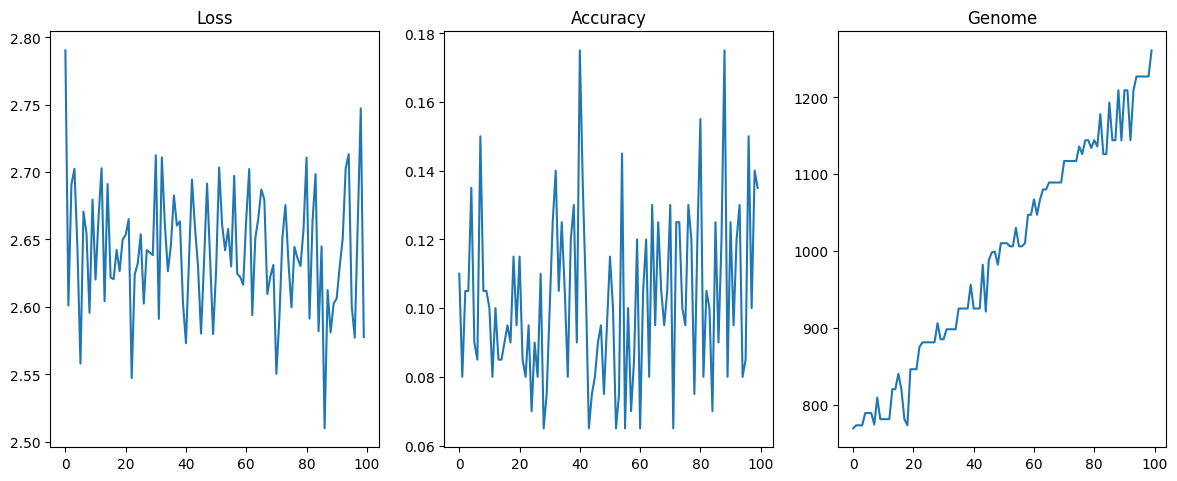

In [ ]:
with torch.no_grad():
    neat_losses = TRAINER.run(50,)


Images: (torch.Size([100, 64, 1, 16, 16]))
Predictions: tensor([[[-1.7812, -2.4375, -2.8281, -2.1562, -5.5625,  2.6562, -5.5938,
           5.5625,  0.6406,  2.5938],
         [-2.6875, -1.7578, -1.3203, -6.2812,  1.8906, -0.9648,  4.6250,
          -4.4375,  0.1235, -0.1152],
         [-0.9531, -2.5156, -2.4844, -2.1094, -2.2656, -0.1318,  4.4062,
          -4.4062, -0.1494, -0.8867]],

        [[-1.2969, -1.6016, -2.6719, -1.7344, -4.7812,  2.2812, -5.0938,
           5.0312,  0.8281,  2.2188],
         [-1.8359, -0.8906, -0.9141, -5.5312,  3.1406, -0.9062,  4.0625,
          -4.5625,  0.2891, -0.2061],
         [-0.8164, -2.0469, -2.9375, -1.1641, -0.8281, -0.1650,  3.2500,
          -4.5000, -0.1040, -1.0312]],

        [[-2.4062, -1.2188, -2.0938, -1.2109, -4.5938,  2.2500, -5.2188,
           5.4062,  0.3242,  2.5469],
         [-2.4531, -0.9023, -0.1543, -5.5312,  2.2969, -0.9141,  4.6250,
          -4.1875,  0.1172,  1.1562],
         [-0.4316, -2.2812, -1.6875, -1.5312, -1.53

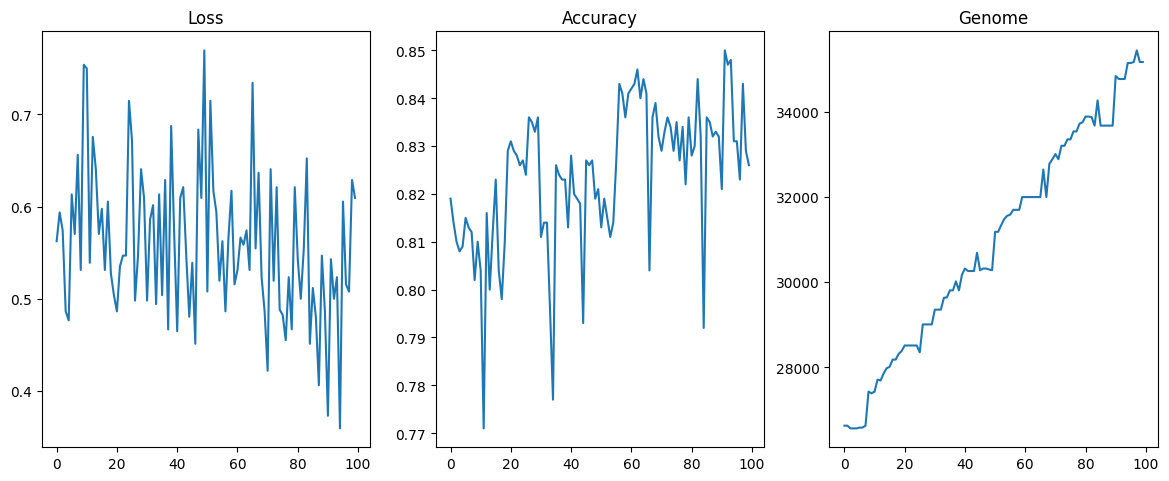

In [ ]:
neat_losses = TRAINER.run(50)

In [83]:
MODEL.eval();

In [85]:
POPULATION.save_dict(name='mnist', file_no=None, replace=False);

Successfully dumped NEAT Population save file to '../../storageneat_save\mnist-8.pkl'.


# Evaluate

In [89]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, mean=True))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, mean=True))*100

(28.081999999999997, 31.182399999999987)

In [104]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100

(16.800000000000004, 21.630000000000006)

In [91]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100

(24.9, 29.900000000000006)

In [92]:
def get_indices(images: Tensor, labels: Tensor, include: Union[int, list[int]] = None,
                faulty: int = False, correct: int = False, shuffle=True,
                keys: Union[int, list[int]] = None):
    if isinstance(include, (int, float)):
        include = [include]
    if keys and not isinstance(keys, (tuple, list)):
        keys = [keys]
    error_indices = []
    mapping = POPULATION.get_mapping(consolidated=True)
    indices = list(range(len(images))) if not keys else [mapping[key] for key in keys]
    images, labels = images[indices], labels[indices]
    if faulty:
        if isinstance(faulty, bool):
            faulty = 16
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], faulty, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys) # shape(genomes, batch_size)
                # print(pred.shape)
                for index, errored in zip(batch, (pred!=labels[:, batch].to(MODEL.device)).mT):
                    # print(errored[:10])
                    if torch.any(errored):
                        error_indices.append(index)
        print(f"Found {len(error_indices)} record predictions with errors")
    valid_indices = []
    if correct:
        if isinstance(correct, bool):
            correct = 16
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], correct, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys)
                for index, correct in zip(batch, (pred==labels[:, batch].to(MODEL.device)).mT):
                    if torch.any(correct):
                        valid_indices.append(index)
        print(f"Found {len(valid_indices)} valid record predictions ")
    indices_filtered = []
    for g_labels in labels.cpu():
        for x, record in enumerate(g_labels.cpu().tolist()):
            record_needed = include is None or record in include
            spec_type = x in error_indices or x in valid_indices
            no_type = not correct and not faulty
            if record_needed and (spec_type or no_type):
                indices_filtered.append(x)
    indices_filtered = list(set(indices_filtered))
    if shuffle:
        random.shuffle(indices_filtered)
    if len(indices_filtered) > 0:
        return indices_filtered
    else:
        raise ValueError(f"No indices available")

In [93]:
test_records = 24
MODEL.eval();

In [94]:
train_indices = get_indices(train_inp, train_out, faulty=BATCH_SIZE, correct=False, keys=POPULATION.best_genome.key)
len(train_indices)

Found 168 record predictions with errors


168

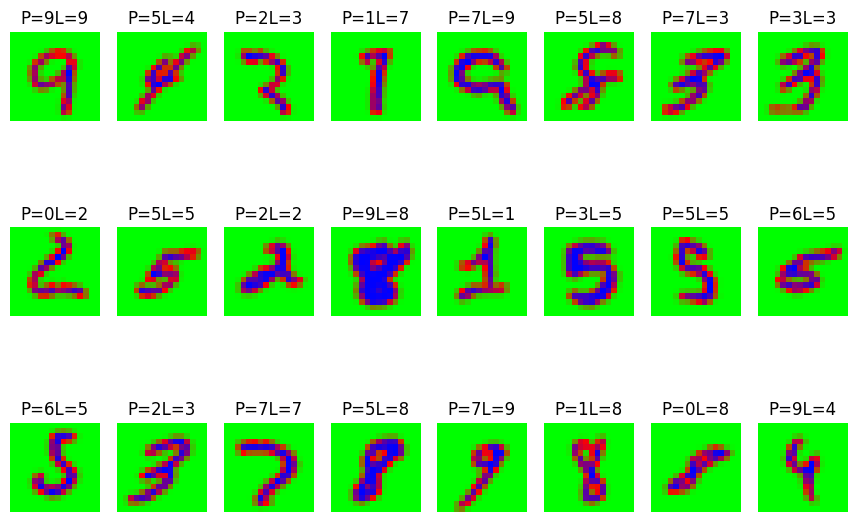

In [95]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [96]:
eval_indices = get_indices(eval_inp, eval_out, faulty=BATCH_SIZE, correct=False, keys=POPULATION.best_genome.key)
len(eval_indices)

Found 2153 record predictions with errors


2153

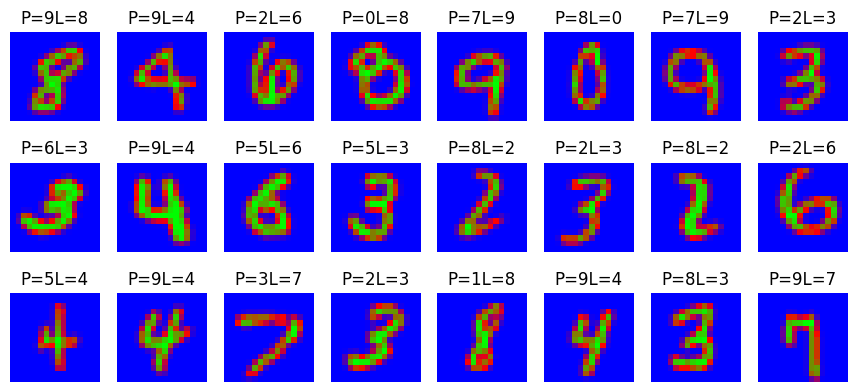

In [97]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

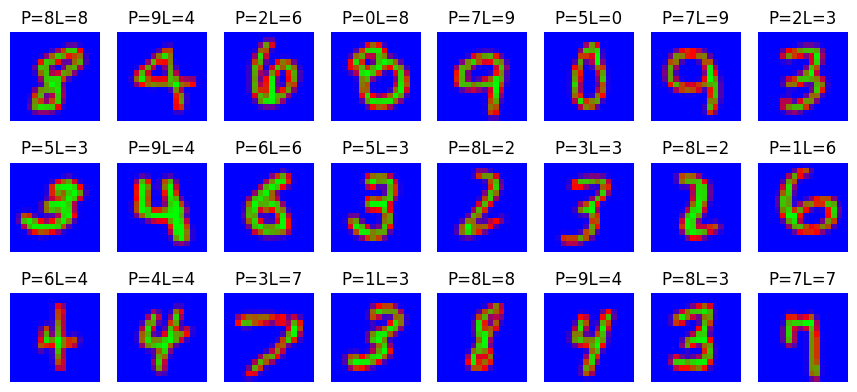

In [98]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

# PyTorch training

In [ ]:
def train2(epochs: int, batch_size: int, key: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    MODEL.requires_grad_(True)
    # attention.causal_mask = False
    optimizer = torch.optim.AdamW(MODEL.parameters(), 1e-3)

    losses = []
    acc_train, acc_eval = [], []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    # ------------------------------ Training Data ------------------------------ #
    index = POPULATION.get_mapping()[key]
    inputs, outputs = train_inp[index].unsqueeze(0).to(MODEL.device), train_out[index].unsqueeze(0).to(MODEL.device)
    print(inputs.shape, outputs.shape)

    best_loss = torch.inf
    best_epoch = -1
    save_state = MODEL.state_dict()
    batches = get_batches(inputs.shape[1], batch_size, True)
    for epoch in range(epochs):
        try:
            loss: Tensor = 0
            for batch in batches:
                # if epoch == 0:
                #     print(inputs.shape, outputs.shape)
                inp = inputs[:, batch].to(MODEL.device)
                out = outputs[0, batch].to(MODEL.device)
                predictions = MODEL(inp, keys=key).squeeze(0)
                # if epoch == 0:
                #     print(inp.shape, predictions.shape, out.shape)
                batch_loss = F.cross_entropy(predictions, out)
                batch_loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                loss += batch_loss
            loss /= len(batches)

            losses.append(loss.cpu().item())
            acc_train.append(get_accuracy(MODEL, train_inp, train_out, batch_size, True, keys=key))
            acc_eval.append(get_accuracy(MODEL, eval_inp, eval_out, batch_size, True, keys=key))

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = MODEL.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item():.4e} | "
                            f"best={best_loss.cpu().item():.4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break
    print(f"\nFinished training in {clock.perf_counter() - ts:.2f}s")

    MODEL.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.close()
        axes = plt.subplots(1, 2, figsize=(10.8, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(np.log10(losses))
        axes[0].set_title('Loss')
        axes[1].plot(acc_train, label='train')
        axes[1].plot(acc_eval, label='eval')
        axes[1].legend()
        axes[1].set_title('Accuracy')

    MODEL.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

In [ ]:
train_losses = train2(100, BATCH_SIZE*8, POPULATION.best_genome.key, checkpoints=1)

In [ ]:
list(POPULATION.genomes.keys())[:15], POPULATION.best_genome

In [ ]:
extra_key = list(POPULATION.genomes.keys())[1]
extra_key

In [ ]:
train2(200, BATCH_SIZE*8, extra_key, checkpoints=1);

In [ ]:
extra_key2 = list(POPULATION.genomes.keys())[3]
extra_key2

In [ ]:
train2(200, BATCH_SIZE*8, extra_key2, checkpoints=1);

In [ ]:
keys_to_check = [*[g.key for g in POPULATION.best_genomes.values()], extra_key, extra_key2]
keys_to_check

In [ ]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, keys=POPULATION.best_genome.key)) * 100

In [ ]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100

In [ ]:
train_indices = get_indices(train_inp, train_out, faulty=None, keys=POPULATION.best_genome.key)

In [ ]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [ ]:
eval_indices = get_indices(eval_inp, eval_out, faulty=BATCH_SIZE*8, correct=False)
len(eval_indices)

In [ ]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

In [ ]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))